To do

1- split then standardize.

2- Write down the built-in function  for ridgeCV and lassoCV in sklearn

3- excercice

4- Information about the data and the task

# ML Regression for Sales.**

---
In this lab, you'll learn how to preprocess tabular data and implement:


1. **Linear Regression** (from scratch)

2. **Ridge Regression**

3. **LASSO Regression**


---

# 📊 **Data**
https://www.kaggle.com/datasets/bumba5341/advertisingcsv

> This dataset's goal is to predict `Sales` (**regression**) based on advertising budgets for TV, Radio, and Newspaper.


# 1️⃣ Import Libraries


LOOK NEXT

In [ ]:
from IPython.display import clear_output

%pip install kagglehub catboost lightgbm tqdm -q

clear_output()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
from tqdm import tqdm

%matplotlib inline

# 2️⃣ Read the Data


In [ ]:
# Download latest version
path = kagglehub.dataset_download("bumba5341/advertisingcsv")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'advertisingcsv' dataset.
Path to dataset files: /kaggle/input/advertisingcsv


In [ ]:
csv_path = os.path.join(path, "Advertising.csv")

df = pd.read_csv(csv_path)
df = df.drop(columns="Unnamed: 0", axis=1)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


# 3️⃣ Exploratory Data Analysis (EDA)

**Rule of thumb checklist:**

| Question | If YES | If NO |
|----------|--------|-------|
|  **Is the target skewed?** | Consider log transform | Proceed |
|  **Missing values?** | Impute or drop | Proceed |
|  **Categorical columns?** | Encode them | Proceed |
|  **Duplicates?** | Drop them | Proceed |
|  **Different scales?** | Standardize  | Proceed |


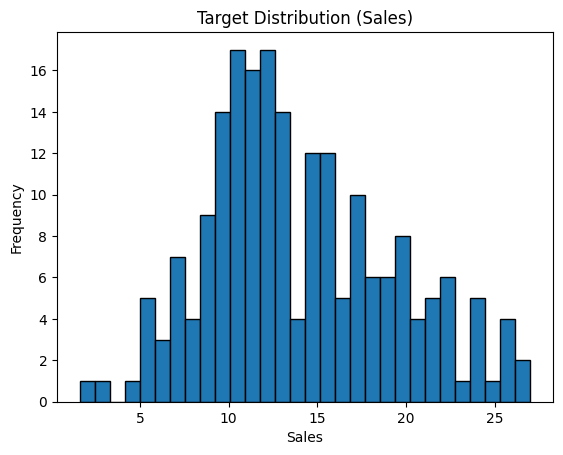

In [ ]:
# 1. What does our target variable (charges) look like?
def check_target_distribution(df, target_column):
  df[target_column].hist(bins=30, edgecolor='black')

  plt.title(f"Target Distribution ({target_column})")
  plt.xlabel(target_column)
  plt.ylabel("Frequency")
  plt.grid(False)

  plt.show()

check_target_distribution(df, "Sales")

> **Rule of thumb:** For regression, if the target is heavily skewed, we might apply a log transform. However, for this lab we'll work with the raw values.


In [ ]:
# 2. Do we have missing values?
def check_missing_values(df):
  missing_values = df.isnull().sum()
  print("Missing Values per Column:")
  print(missing_values[missing_values > 0])
  if missing_values.any():
    print("\nHandle Missing Values as needed.")
  else:
    print("\nNo Missing Values Found.")

check_missing_values(df)

Missing Values per Column:
Series([], dtype: int64)

No Missing Values Found.


In [ ]:
# 3. Do we have categorical columns?
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical Columns:", list(categorical_cols))

Categorical Columns: []


> We don't have categorical columns. If we did, we would need to encode them (convert them into numbers) for our models.

In [ ]:
# 4. Do we have duplicate samples?
def check_duplicates(df):
  duplicates = df.duplicated().sum()
  print(f"Number of Duplicate Samples: {duplicates}")
  if duplicates > 0:
    print("Dropping Duplicates...")
    df.drop_duplicates(inplace=True)
    print("Duplicates Dropped.")
  else:
    print("No Duplicate Samples Found.")

check_duplicates(df)

Number of Duplicate Samples: 0
No Duplicate Samples Found.


> **Rule of thumb:** If duplicates exist, drop them with `df.drop_duplicates(inplace=True)`


In [ ]:
# 5. Do we have different scales in the data?
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


> **Rule of thumb:** If features have vastly different ranges, then **scale them**. Scaling won't hurt, and it's recommended regardless.
>
> Tree models (RF, LightGBM, CatBoost) don't need scaling, but Linear Regression, Ridge, LASSO, SVM do!


In [ ]:
from sklearn.preprocessing import MinMaxScaler

features = df.columns.drop("Sales")  # DON'T SCALE THE TARGET

scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])
df.head()

,TV,Radio,Newspaper,Sales
0,0.775786,0.762097,0.605981,22.1
1,0.148123,0.792339,0.394019,10.4
2,0.055800,0.925403,0.606860,9.3
3,0.509976,0.832661,0.511873,18.5
4,0.609063,0.217742,0.510994,12.9


# 4️⃣ Training our Regression Models

> We need to split our data into **X** (features) and **y** (target).


In [ ]:
X = df.drop("Sales", axis=1).astype(float)
y = df['Sales'].astype(float)

---

# Part A: Linear Regression from Scratch

### **Linear Regression Model**

Linear regression predicts a continuous target value by finding the best linear relationship between features and target:

$$\hat{y} = X \cdot \theta$$

Where:
- $X$ = feature matrix (with bias term)
- $\theta$ = weight vector (parameters to learn)
- $\hat{y}$ = predicted values

---

### **Mean Squared Error Loss (MSE)**

We use **Mean Squared Error** to measure how well our predictions match the true values:

$$J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2$$

Where:
- $m$ = number of samples
- $y_i$ = true value
- $\hat{y}_i$ = predicted value

> **Intuition:** If we predict the exact value, MSE is 0. The bigger the difference, the higher the penalty (and it's squared, so large errors are penalized heavily)!

In [ ]:
# Mean Squared Error in NumPy
def mean_squared_error(y, y_hat):
  return (1 / (2 * len(y))) * np.sum((y_hat - y) ** 2)

In [ ]:
def normal_equation(X, y):
   # Add bias term (intercept)
    m = X.shape[0]
    X_b = np.c_[np.ones((m, 1)), X]

    # Closed-form solution using pseudoinverse
    theta = np.linalg.pinv(X_b.T @ X_b) @ X_b.T @ y

    return theta

**Training Linear Regression** using K-Fold Cross-Validation

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error as sklearn_mse, mean_absolute_error, r2_score

In [ ]:
n_splits = 5  # K=5 Folds

# 5-Fold Cross-Validation, shuffled
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

In [ ]:
# Storage for linear regression results for each fold
train_mse_list = []
test_mse_list = []

train_rmse_list = []
test_rmse_list = []

train_r2_list = []
test_r2_list = []

In [ ]:
for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"\nFold {fold_idx + 1}/{n_splits}")

    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Train (closed form)
    theta = normal_equation(X_train.values, y_train.values)

    # Add bias column
    X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train.values]
    X_test_b  = np.c_[np.ones((X_test.shape[0], 1)),  X_test.values]

    # Predictions
    y_train_pred = X_train_b @ theta
    y_test_pred  = X_test_b @ theta

    # Metrics
    train_mse = sklearn_mse(y_train, y_train_pred)
    test_mse  = sklearn_mse(y_test, y_test_pred)

    train_rmse = np.sqrt(train_mse)
    test_rmse  = np.sqrt(test_mse)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2  = r2_score(y_test, y_test_pred)

    # Store
    train_mse_list.append(train_mse)
    test_mse_list.append(test_mse)

    train_rmse_list.append(train_rmse)
    test_rmse_list.append(test_rmse)

    train_r2_list.append(train_r2)
    test_r2_list.append(test_r2)

    print(f"Train MSE: {train_mse:.4f} | Test MSE: {test_mse:.4f}")
    print(f"Train MSE: {train_rmse:.4f} | Test MSE: {test_rmse:.4f}")
    print(f"Train MSE: {train_r2:.4f} | Test MSE: {test_r2:.4f}")


Fold 1/5
Train MSE: 2.7051 | Test MSE: 3.1741
Train MSE: 1.6447 | Test MSE: 1.7816
Train MSE: 0.8957 | Test MSE: 0.8994

Fold 2/5
Train MSE: 2.6814 | Test MSE: 3.2937
Train MSE: 1.6375 | Test MSE: 1.8149
Train MSE: 0.9060 | Test MSE: 0.8190

Fold 3/5
Train MSE: 3.0870 | Test MSE: 1.6228
Train MSE: 1.7570 | Test MSE: 1.2739
Train MSE: 0.8863 | Test MSE: 0.9340

Fold 4/5
Train MSE: 2.8259 | Test MSE: 2.8297
Train MSE: 1.6810 | Test MSE: 1.6822
Train MSE: 0.8939 | Test MSE: 0.9010

Fold 5/5
Train MSE: 2.5209 | Test MSE: 3.9051
Train MSE: 1.5877 | Test MSE: 1.9761
Train MSE: 0.9062 | Test MSE: 0.8603


**Linear Regression Loss Curve**

> use `np.mean(..)` to get the average across all folds.


In [ ]:
print("Linear Regression Results")

print(f"  Average Train MSE: {np.mean(train_mse_list):.4f}")
print(f"  Average Test  MSE: {np.mean(test_mse_list):.4f}")

print(f"  Average Train RMSE: {np.mean(train_rmse_list):.4f}")
print(f"  Average Test  RMSE: {np.mean(test_rmse_list):.4f}")

print(f"  Average Train R2: {np.mean(train_r2_list):.4f}")
print(f"  Average Test  R2: {np.mean(test_r2_list):.4f}")

Linear Regression Results
  Average Train MSE: 2.7641
  Average Test  MSE: 2.9651
  Average Train RMSE: 1.6616
  Average Test  RMSE: 1.7057
  Average Train R2: 0.8976
  Average Test  R2: 0.8827


---

# Part B: Scikit-Learn Regression Models

In [ ]:
from sklearn.linear_model import Ridge, Lasso
#from sklearn.svm import SVR
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.ensemble import RandomForestRegressor
#from lightgbm import LGBMRegressor
#from catboost import CatBoostRegressor

In [ ]:
models = {
  "Ridge Regression": Ridge(alpha=1.0, max_iter=10000),
  "LASSO Regression": Lasso(alpha=1.0,  max_iter=10000),
}

In [ ]:
# Storage for results
all_results = {}

for name in models:
  all_results[name] = {'mse': [], 'rmse': [], 'r2': []}

In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold_idx, (train_index, test_index) in enumerate(kf.split(X)):
  print(f"\nFold {fold_idx + 1}/{n_splits}")

  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  for model_name, model in models.items():
    print(f"Training {model_name}...")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Calculate metrics
    mse = sklearn_mse(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # Store results
    all_results[model_name]["mse"].append(mse)
    all_results[model_name]["rmse"].append(rmse)
    all_results[model_name]["r2"].append(r2)


Fold 1/5
Training Ridge Regression...
Training LASSO Regression...

Fold 2/5
Training Ridge Regression...
Training LASSO Regression...

Fold 3/5
Training Ridge Regression...
Training LASSO Regression...

Fold 4/5
Training Ridge Regression...
Training LASSO Regression...

Fold 5/5
Training Ridge Regression...
Training LASSO Regression...


# 5️⃣ Results Comparison


In [ ]:
for model_name in all_results:
  print(f"\n{model_name}:")
  print(f"  MSE:  {np.mean(all_results[model_name]['mse']):.4f}")
  print(f"  RMSE: {np.mean(all_results[model_name]['rmse']):.4f}")
  print(f"  R2:    {np.mean(all_results[model_name]['r2']):.4f}")


Ridge Regression:
  MSE:  3.0722
  RMSE: 1.7402
  R2:    0.8797

LASSO Regression:
  MSE:  23.0397
  RMSE: 4.7859
  R2:    0.1141


---

## Are our models good?

>Is RMSE = 1.00 good? How to know if a score is good or not?
>
>We need something to compare against. We need a Baseline.
>
>If our models are better than the baseline score, then they are good.

**The simplest baseline we can consider is the mean of the target**.

In [ ]:
# Calculate the baseline predictions (mean of the target)
baseline_pred = np.full_like(y, y.mean())

# Evaluate the baseline
baseline_mse = sklearn_mse(y, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y, baseline_pred)

print(f"Baseline MSE (using mean target): {baseline_mse:.4f}")
print(f"Baseline RMSE (using mean target): {baseline_rmse:.4f}")
print(f"Baseline R2 (using mean target): {baseline_r2:.4f}")

Baseline MSE (using mean target): 27.0857
Baseline RMSE (using mean target): 5.2044
Baseline R2 (using mean target): 0.0000


> **Our models are way better than this baseline because our MSE are lower than the baseline MSE (variance)


# 6️⃣ Feature Importance (Ridge & LASSO)

> For linear models like Ridge and LASSO, the coefficients tell us how important each feature is. Larger absolute values = more important features.

Linear models use coefficients `.coef_` a.k.a weights for each feature

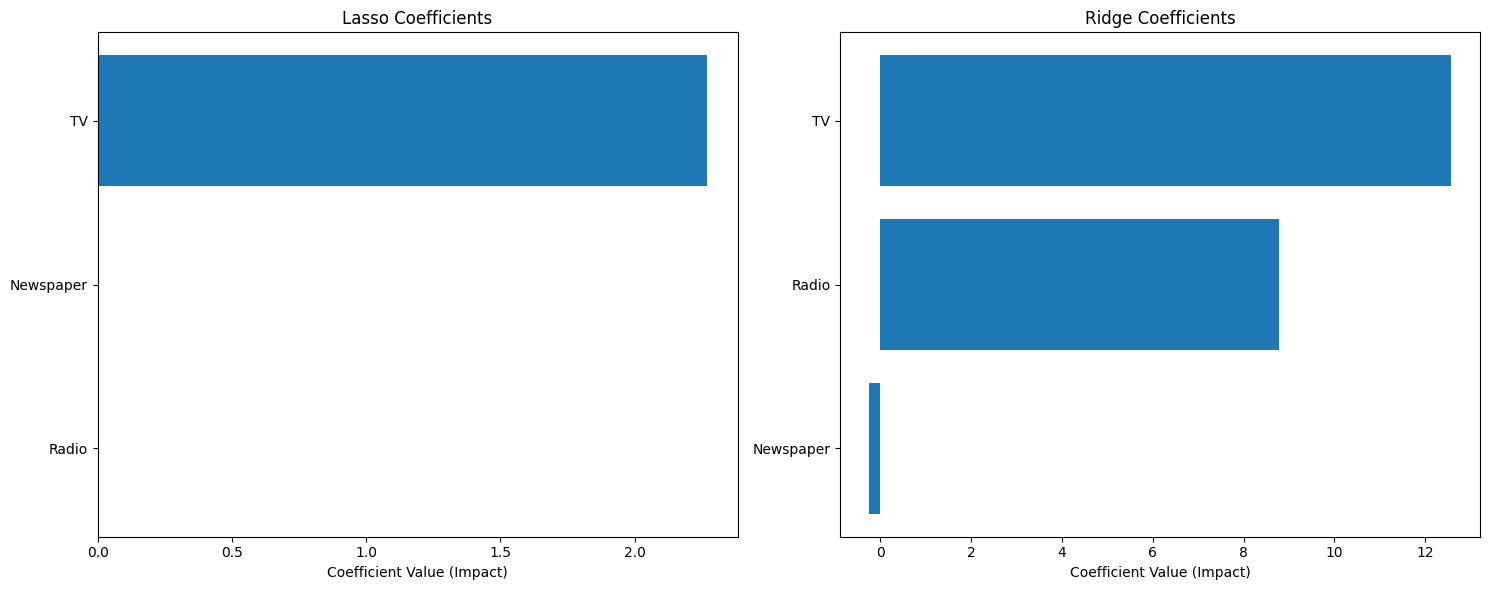

In [ ]:
coeffs = {}

coeffs['Lasso'] = models['LASSO Regression'].coef_
coeffs['Ridge'] = models['Ridge Regression'].coef_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.flatten()
features = X.columns

for i, (model_name, coef) in enumerate(coeffs.items()):
  # Sort features by absolute coefficient value
  absolute_coef = np.abs(coef)
  sorted_idx = np.argsort(absolute_coef)

  ax = axes[i]
  ax.barh(features[sorted_idx], coef[sorted_idx])
  ax.set_title(f"{model_name} Coefficients")
  ax.set_xlabel("Coefficient Value (Impact)")

plt.tight_layout()
plt.show()

> **Observation:**
> - LASSO (L1 regularization) pushes some coefficients to exactly 0, effectively performing feature selection (TV).
>
> - Ridge (L2 regularization) smoothly shrinks coefficients but rarely sets them to 0.

### **Contribution: Sattam Altwaim** :)